# Нейросетевая классификация патологий ритма сердца

Этот ноутбук обучает **1D-CNN модель** для классификации сердечных сокращений на 5 классов по стандарту AAMI:

- **N** - Normal (нормальные)
- **S** - Supraventricular ectopic (наджелудочковые экстрасистолы)
- **V** - Ventricular ectopic (желудочковые экстрасистолы)
- **F** - Fusion (сливные комплексы)
- **Q** - Unknown (артефакты/неизвестные)

## Архитектура

Используется **1D Convolutional Neural Network** с residual-блоками это стандартная архитектура для классификации ЭКГ. Свёртки эффективно извлекают локальные морфологические признаки QRS-комплекса, а residual-связи стабилизируют обучение.

## Входные данные

Файл `mitbih_balanced.npz`, содержащий три варианта обучающей выборки:
1. Исходная несбалансированная + взвешенный loss
2. После SMOTE
3. После аугментаций сигнала

## 1. Импорт библиотек

In [2]:
# !pip install torch numpy matplotlib scikit-learn seaborn tqdm

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score, accuracy_score
)

# Фиксация seed для воспроизводимости
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Устройство: cpu


## 2. Загрузка сбалансированных данных

In [4]:
data = np.load('./models/mitbih_balanced.npz', allow_pickle=True)

print('Доступные ключи:')
for key in data.files:
    arr = data[key]
    if arr.ndim == 0:
        print(f'  {key:20s} | scalar = {arr}')
    else:
        print(f'  {key:20s} | shape = {arr.shape}')

CLASS_NAMES = list(data['class_names'])
N_CLASSES = len(CLASS_NAMES)
print(f'\nКлассы: {CLASS_NAMES}')

Доступные ключи:
  X_train              | shape = (51001, 250)
  y_train              | shape = (51001,)
  X_train_smote        | shape = (137539, 250)
  y_train_smote        | shape = (137539,)
  X_train_aug          | shape = (106975, 250)
  y_train_aug          | shape = (106975,)
  X_test               | shape = (49691, 250)
  y_test               | shape = (49691,)
  class_weights        | shape = (5,)
  sample_weights       | shape = (51001,)
  class_names          | shape = (5,)
  fs                   | scalar = 360

Классы: ['N', 'S', 'V', 'F', 'Q']


### Выбор стратегии балансировки

Можно переключаться между тремя вариантами:
- `'aug'` - аугментации сигнала **(рекомендуется для ЭКГ)**
- `'smote'` - SMOTE-интерполяция
- `'weighted'` - несбалансированные данные + взвешенный loss

In [5]:
STRATEGY = 'aug'  # 'aug' | 'smote' | 'weighted'

if STRATEGY == 'aug':
    X_train = data['X_train_aug']
    y_train = data['y_train_aug']
    use_weighted_loss = False
elif STRATEGY == 'smote':
    X_train = data['X_train_smote']
    y_train = data['y_train_smote']
    use_weighted_loss = False
elif STRATEGY == 'weighted':
    X_train = data['X_train']
    y_train = data['y_train']
    use_weighted_loss = True
else:
    raise ValueError(f'Unknown strategy: {STRATEGY}')

X_test = data['X_test']
y_test = data['y_test']
class_weights = data['class_weights']

print(f'Стратегия: {STRATEGY}')
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Взвешенный loss: {use_weighted_loss}')

Стратегия: aug
Train: (106975, 250), Test: (49691, 250)
Взвешенный loss: False


### Валидационная выборка

Выделяем 15% обучающей выборки для отслеживания переобучения. Используем стратификацию для сохранения баланса классов.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=SEED
)

print(f'Train: {X_train.shape}')
print(f'Val:   {X_val.shape}')
print(f'Test:  {X_test.shape}')

Train: (90928, 250)
Val:   (16047, 250)
Test:  (49691, 250)


## 3. PyTorch Dataset и DataLoader

Создаём  `Dataset` для удобной работы с PyTorch.
Сигнал ЭКГ имеет shape `(250,)`, но для 1D-свёртки нужен формат `(C, T)` = `(1, 250)`, где `C` - число каналов.

In [5]:
class ECGDataset(Dataset):
    """Dataset для ЭКГ-сегментов."""
    
    def __init__(self, X, y):
        # Добавляем размерность канала: (N, 250) - (N, 1, 250)
        self.X = torch.from_numpy(X).float().unsqueeze(1)
        self.y = torch.from_numpy(y).long()
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 256

train_ds = ECGDataset(X_train, y_train)
val_ds = ECGDataset(X_val, y_val)
test_ds = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

# Проверка формы батча
x_sample, y_sample = next(iter(train_loader))
print(f'\nФорма батча X: {x_sample.shape} (batch, channels, time)')
print(f'Форма батча y: {y_sample.shape}')

Train batches: 356
Val batches:   63
Test batches:  195

Форма батча X: torch.Size([256, 1, 250]) (batch, channels, time)
Форма батча y: torch.Size([256])


## 4. Архитектура нейросети: 1D ResNet

Используем сверточную сеть с **residual-блоками**:

### Структура
1. **Stem** - начальный свёрточный слой для извлечения базовых признаков
2. **3 residual-блока** с возрастающим числом каналов (32 - 64 - 128)
3. **Global Average Pooling** - агрегация по временной оси
4. **Dropout + Linear** - классификатор

### Residual-блоки
Residual-связи $y = F(x) + x$ позволяют обучать более глубокие сети без проблем с затухающими градиентами. Для ЭКГ это особенно важно, так как одновременно нужны:
- **Локальные признаки** (форма QRS-комплекса)
- **Глобальные признаки** (общая форма цикла)

In [6]:
class ResidualBlock1D(nn.Module):
      
    def __init__(self, in_channels, out_channels, kernel_size=5, stride=1, dropout=0.2):
        super().__init__()
        padding = kernel_size // 2
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                                stride=stride, padding=padding, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                                stride=1, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.dropout = nn.Dropout(dropout)
        
        # Shortcut для согласования размерностей
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()
    
    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out = out + identity
        return F.relu(out)


class ECGResNet(nn.Module):
    """
    1D ResNet для классификации ЭКГ-сегментов.
    
    Параметры:
    ----------
    n_classes : int
        Количество классов
    base_channels : int
        Базовое количество каналов
    dropout : float
        Вероятность dropout
    """
    
    def __init__(self, n_classes=5, base_channels=32, dropout=0.3):
        super().__init__()
        
        # Stem: начальное извлечение признаков
        self.stem = nn.Sequential(
            nn.Conv1d(1, base_channels, kernel_size=7, stride=1, padding=3, bias=False),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),  # 250 - 125
        )
        
        # Residual-блоки с увеличением каналов и уменьшением длины
        self.block1 = ResidualBlock1D(base_channels, base_channels, stride=1, dropout=0.2)
        self.block2 = ResidualBlock1D(base_channels, base_channels*2, stride=2, dropout=0.2)  # 125 - 63
        self.block3 = ResidualBlock1D(base_channels*2, base_channels*4, stride=2, dropout=0.3)  # 63 - 32
        
        # Global Average Pooling агрегирует временную ось
        self.gap = nn.AdaptiveAvgPool1d(1)
        
        # Классификатор
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(base_channels*4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )
    
    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


# Инициализация и проверка
model = ECGResNet(n_classes=N_CLASSES, base_channels=32, dropout=0.3).to(DEVICE)

# Подсчёт параметров
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Количество обучаемых параметров: {n_params:,}')

# Проверка forward pass
with torch.no_grad():
    test_input = torch.randn(2, 1, 250).to(DEVICE)
    test_output = model(test_input)
    print(f'Вход:  {test_input.shape}')
    print(f'Выход: {test_output.shape}')

Количество обучаемых параметров: 184,229
Вход:  torch.Size([2, 1, 250])
Выход: torch.Size([2, 5])


## 5. Настройка обучения

### Функция потерь
Используем **CrossEntropyLoss** (с весами классов, если выбрана стратегия `'weighted'`).

### Оптимизатор
**Adam** - хорошо работает для большинства задач.

### Scheduler
**ReduceLROnPlateau** уменьшает learning rate при выходе на плато по валидационному loss.

In [7]:
# Функция потерь
if use_weighted_loss:
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    print(f'Используется взвешенный CrossEntropyLoss с весами: {class_weights}')
else:
    criterion = nn.CrossEntropyLoss()
    print('Используется обычный CrossEntropyLoss')

# Оптимизатор
LR = 1e-3
WEIGHT_DECAY = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f'\nОптимизатор: Adam, lr={LR}, weight_decay={WEIGHT_DECAY}')

Используется обычный CrossEntropyLoss

Оптимизатор: Adam, lr=0.001, weight_decay=0.0001


## 6. Функции обучения и валидации

In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Одна эпоха обучения."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * x.size(0)
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_labels.append(y.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    
    return avg_loss, acc, f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Оценка модели на выборке."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        
        total_loss += loss.item() * x.size(0)
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_labels.append(y.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    
    return avg_loss, acc, f1, preds, labels

## 7. Обучение модели

Используем **Early Stopping** - останавливаем обучение, если макро-F1 на валидации не растёт в течение `patience` эпох.


При дисбалансе классов accuracy завышена. Macro-F1 усредняет F1 по классам с равным весом, поэтому миноритарные классы важны так же, как мажоритарные.

## 8. Цикл обучения

In [11]:
N_EPOCHS = 30
PATIENCE = 7  # Early Stopping: остановка, если F1 не растёт N эпох
BEST_MODEL_PATH = 'best_ecg_model.pth'

# История метрик для визуализации
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': [],
    'train_f1': [],   'val_f1': [],
    'lr': []
}

best_val_f1 = 0.0
epochs_no_improve = 0

print(f'Начало обучения на {DEVICE}')
print(f'Стратегия: {STRATEGY} | Эпох: {N_EPOCHS} | Patience: {PATIENCE}')
print('=' * 80)

for epoch in range(1, N_EPOCHS + 1):
    # === Обучение ===
    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    
    # === Валидация ===
    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )
    
    # === Scheduler ===
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # === Сохранение истории ===
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    
    # === Логирование ===
    marker = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
            'val_acc': val_acc,
        }, BEST_MODEL_PATH)
        marker = ' ★ (saved)'
    else:
        epochs_no_improve += 1
    
    print(f'Эпоха {epoch:3d}/{N_EPOCHS} | '
          f'Train loss={train_loss:.4f} acc={train_acc:.4f} f1={train_f1:.4f} | '
          f'Val loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f} | '
          f'lr={current_lr:.1e}{marker}')
    
    # === Early Stopping ===
    if epochs_no_improve >= PATIENCE:
        print(f'\n⚠ Early stopping: F1 не улучшается {PATIENCE} эпох')
        break

print('=' * 80)
print(f'✓ Обучение завершено. Лучший val F1 = {best_val_f1:.4f}')
print(f'✓ Модель сохранена в {BEST_MODEL_PATH}')

Начало обучения на cpu
Стратегия: aug | Эпох: 30 | Patience: 7
Эпоха   1/30 | Train loss=0.3413 acc=0.8885 f1=0.8731 | Val loss=0.1906 acc=0.9483 f1=0.9426 | lr=1.0e-03 ★ (saved)
Эпоха   2/30 | Train loss=0.1371 acc=0.9586 f1=0.9530 | Val loss=0.0752 acc=0.9771 f1=0.9747 | lr=1.0e-03 ★ (saved)
Эпоха   3/30 | Train loss=0.1073 acc=0.9666 f1=0.9623 | Val loss=0.0639 acc=0.9792 f1=0.9768 | lr=1.0e-03 ★ (saved)
Эпоха   4/30 | Train loss=0.0895 acc=0.9725 f1=0.9689 | Val loss=0.0493 acc=0.9846 f1=0.9830 | lr=1.0e-03 ★ (saved)
Эпоха   5/30 | Train loss=0.0783 acc=0.9759 f1=0.9729 | Val loss=0.0516 acc=0.9837 f1=0.9820 | lr=1.0e-03
Эпоха   6/30 | Train loss=0.0666 acc=0.9793 f1=0.9769 | Val loss=0.0434 acc=0.9864 f1=0.9851 | lr=1.0e-03 ★ (saved)
Эпоха   7/30 | Train loss=0.0627 acc=0.9805 f1=0.9781 | Val loss=0.0381 acc=0.9870 f1=0.9857 | lr=1.0e-03 ★ (saved)
Эпоха   8/30 | Train loss=0.0542 acc=0.9829 f1=0.9808 | Val loss=0.0396 acc=0.9864 f1=0.9852 | lr=1.0e-03
Эпоха   9/30 | Train loss=0.0

## 9. Визуализация процесса обучения

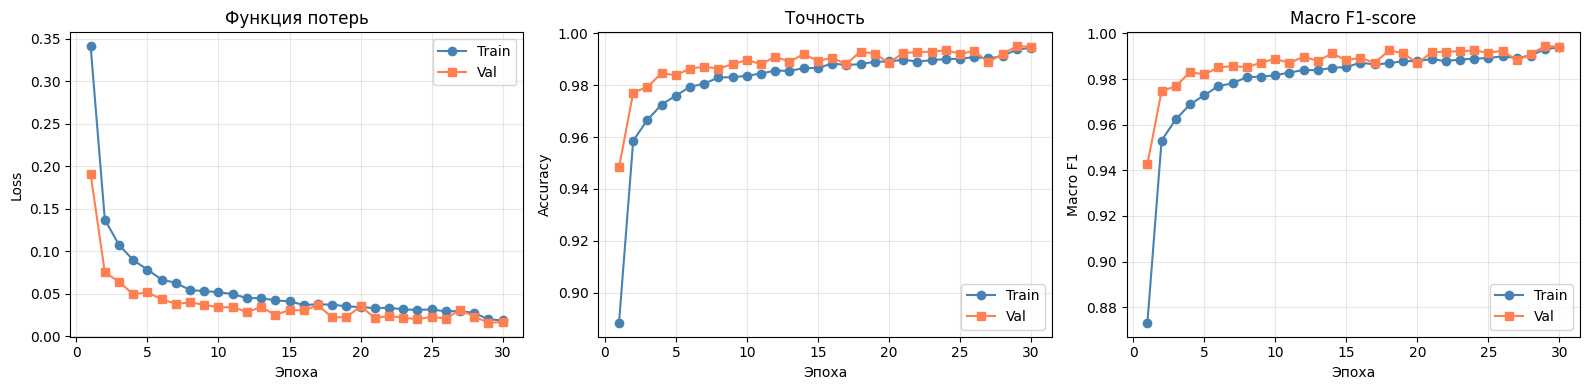

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'], 's-', label='Val', color='coral')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Функция потерь')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train', color='steelblue')
axes[1].plot(epochs_range, history['val_acc'], 's-', label='Val', color='coral')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Точность')
axes[1].legend()
axes[1].grid(alpha=0.3)

# F1
axes[2].plot(epochs_range, history['train_f1'], 'o-', label='Train', color='steelblue')
axes[2].plot(epochs_range, history['val_f1'], 's-', label='Val', color='coral')
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('Macro F1')
axes[2].set_title('Macro F1-score')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Оценка на тестовой выборке

In [15]:
# Загружаем лучшую модель

BEST_MODEL_PATH = 'best_ecg_model.pth'
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Загружена модель с эпохи {checkpoint["epoch"]} (val F1 = {checkpoint["val_f1"]:.4f})')

# Оценка на тесте
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

print('\n' + '=' * 60)
print('Метрики на тестовой выборке')
print('=' * 60)
print(f'Loss:     {test_loss:.4f}')
print(f'Accuracy: {test_acc:.4f}')
print(f'Macro F1: {test_f1:.4f}')

# Подробный отчёт по классам
print('\nClassification Report:')
print(classification_report(
    test_labels, test_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

Загружена модель с эпохи 29 (val F1 = 0.9944)

Метрики на тестовой выборке
Loss:     0.6565
Accuracy: 0.8340
Macro F1: 0.3351

Classification Report:
              precision    recall  f1-score   support

           N     0.9539    0.8644    0.9069     44239
           S     0.0468    0.0947    0.0627      1837
           V     0.5486    0.9391    0.6926      3220
           F     0.0134    0.0129    0.0132       388
           Q     0.0000    0.0000    0.0000         7

    accuracy                         0.8340     49691
   macro avg     0.3126    0.3822    0.3351     49691
weighted avg     0.8866    0.8340    0.8547     49691



## 11. Confusion Matrix

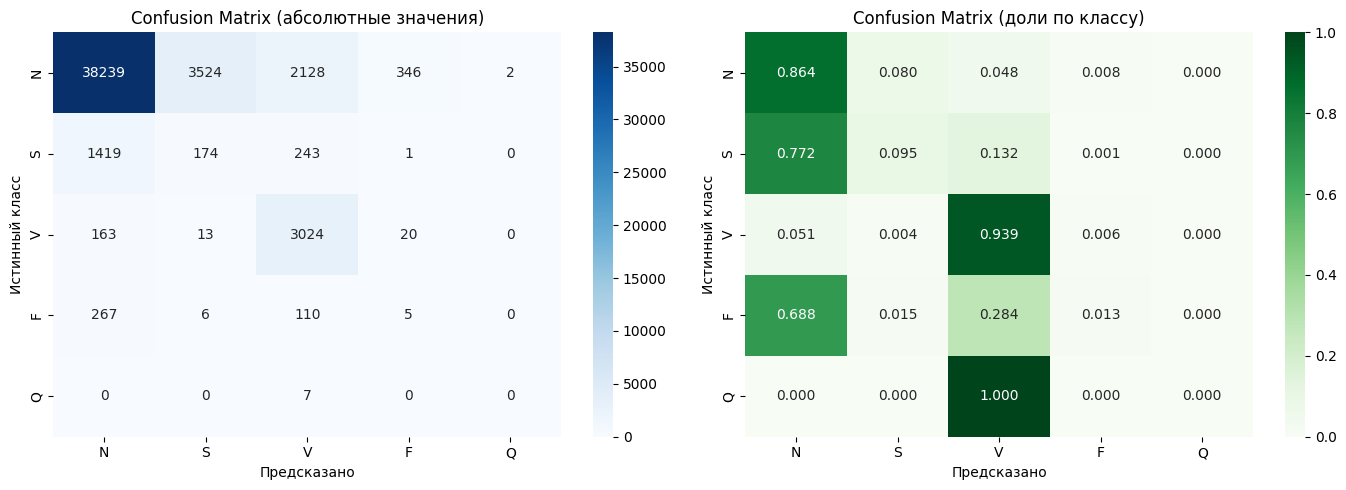


Детализированные метрики по классам:
------------------------------------------------------------
Класс     Precision     Recall         F1    Support
------------------------------------------------------------
N            0.9539     0.8644     0.9069      44239
S            0.0468     0.0947     0.0627       1837
V            0.5486     0.9391     0.6926       3220
F            0.0134     0.0129     0.0132        388
Q            0.0000     0.0000     0.0000          7


In [16]:
cm = confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Абсолютные значения
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], cbar=True)
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Истинный класс')
axes[0].set_title('Confusion Matrix (абсолютные значения)')

# Нормализованная по строкам (доля правильных в классе)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], cbar=True, vmin=0, vmax=1)
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истинный класс')
axes[1].set_title('Confusion Matrix (доли по классу)')

plt.tight_layout()
plt.show()

# Метрики по каждому классу
print('\nДетализированные метрики по классам:')
print('-' * 60)
print(f'{"Класс":<8} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
print('-' * 60)
for i, name in enumerate(CLASS_NAMES):
    p = precision_score(test_labels, test_preds, labels=[i], average='macro', zero_division=0)
    r = recall_score(test_labels, test_preds, labels=[i], average='macro', zero_division=0)
    f = f1_score(test_labels, test_preds, labels=[i], average='macro', zero_division=0)
    s = int(np.sum(test_labels == i))
    print(f'{name:<8} {p:>10.4f} {r:>10.4f} {f:>10.4f} {s:>10}')

## 12. Визуализация примеров предсказаний

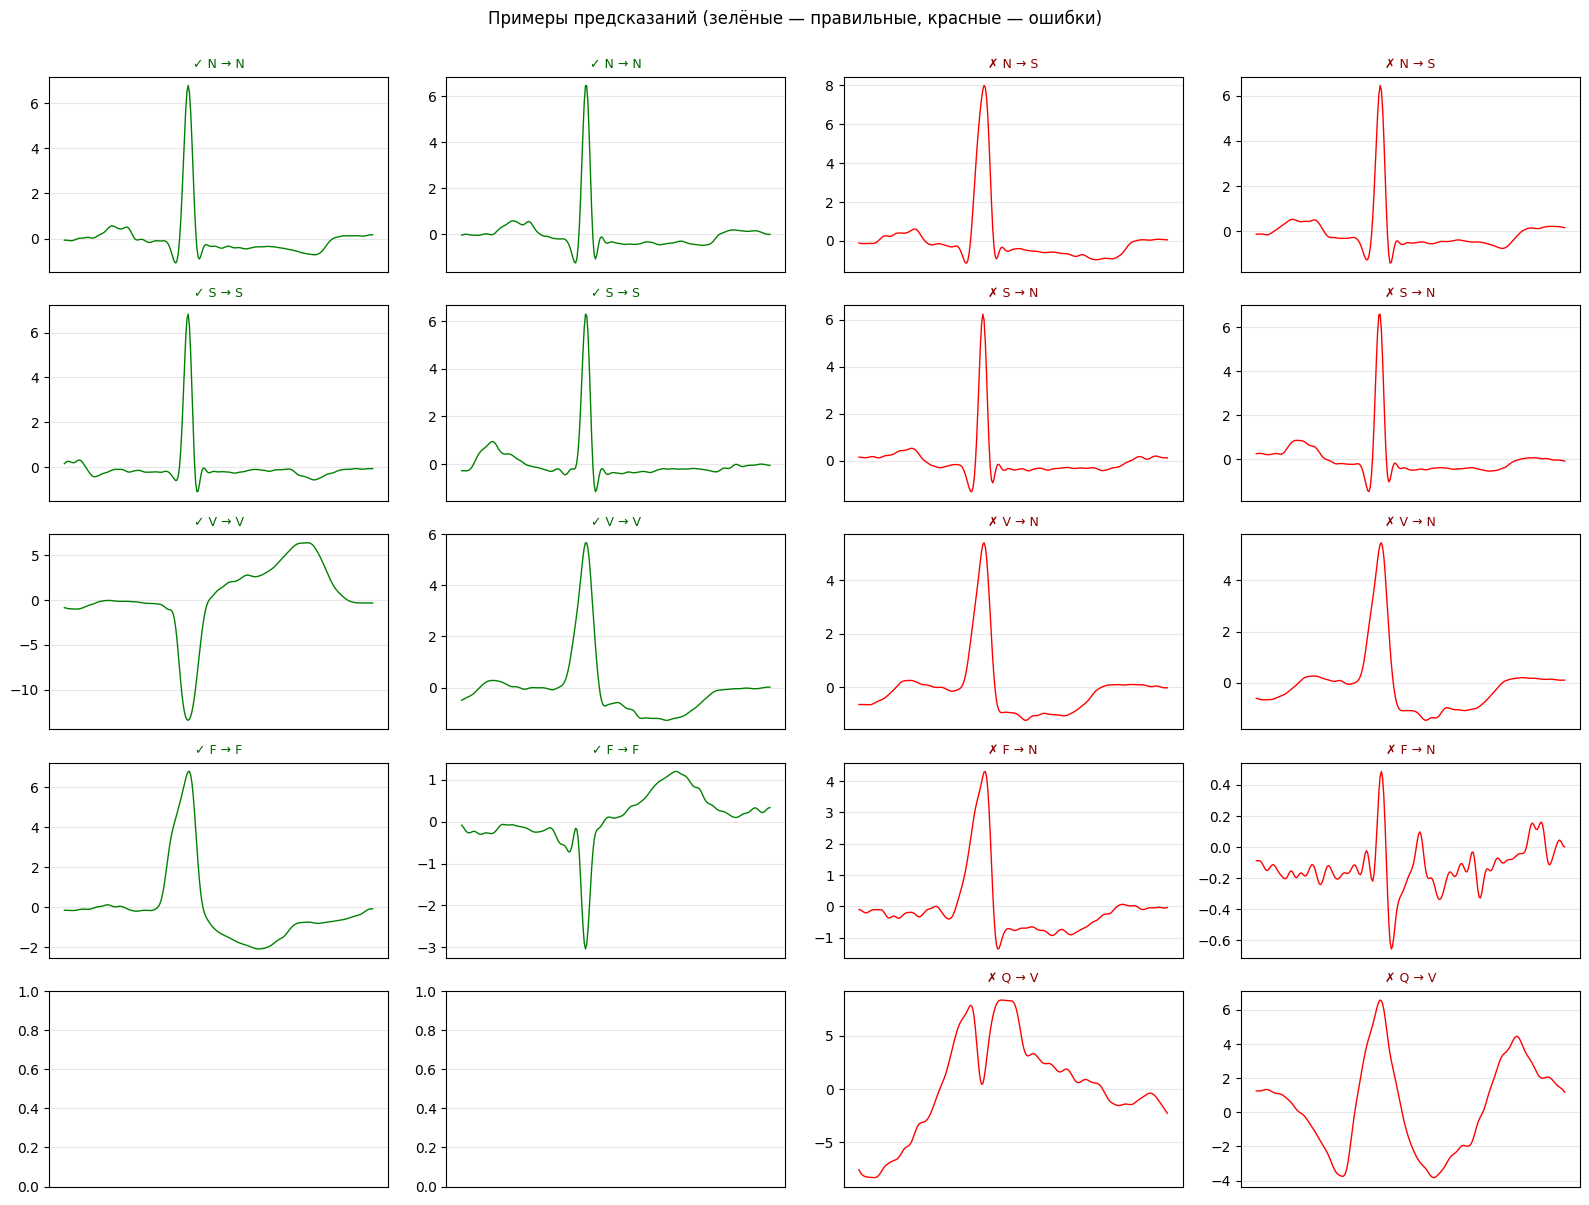

In [17]:
def plot_predictions(X, y_true, y_pred, n_per_class=2):
    """Показывает примеры правильных и ошибочных предсказаний для каждого класса."""
    fig, axes = plt.subplots(N_CLASSES, n_per_class * 2, figsize=(16, 12))
    
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        # Правильные предсказания
        correct_idx = np.where((y_true == cls_idx) & (y_pred == cls_idx))[0]
        # Ошибочные предсказания
        wrong_idx = np.where((y_true == cls_idx) & (y_pred != cls_idx))[0]
        
        # Правильные (зелёные)
        for j in range(n_per_class):
            ax = axes[cls_idx, j]
            if len(correct_idx) > j:
                idx = correct_idx[j]
                ax.plot(X[idx].squeeze(), color='green', linewidth=1)
                ax.set_title(f'✓ {cls_name} → {CLASS_NAMES[y_pred[idx]]}',
                            fontsize=9, color='darkgreen')
            ax.grid(alpha=0.3)
            ax.set_xticks([])
        
        # Ошибочные (красные)
        for j in range(n_per_class):
            ax = axes[cls_idx, n_per_class + j]
            if len(wrong_idx) > j:
                idx = wrong_idx[j]
                ax.plot(X[idx].squeeze(), color='red', linewidth=1)
                ax.set_title(f'✗ {cls_name} → {CLASS_NAMES[y_pred[idx]]}',
                            fontsize=9, color='darkred')
            ax.grid(alpha=0.3)
            ax.set_xticks([])
    
    plt.suptitle('Примеры предсказаний (зелёные — правильные, красные — ошибки)',
                 fontsize=12, y=1.00)
    plt.tight_layout()
    plt.show()


plot_predictions(X_test, test_labels, test_preds, n_per_class=2)

## 13. Сохранение финальной модели и результатов

In [18]:
# Сохранение модели + метаинформации в одном файле
torch.save({
    'model_state_dict': model.state_dict(),
    'model_class': 'ECGResNet',
    'model_config': {
        'n_classes': N_CLASSES,
        'base_channels': 32,
        'dropout': 0.3,
    },
    'class_names': CLASS_NAMES,
    'strategy': STRATEGY,
    'test_metrics': {
        'accuracy': test_acc,
        'macro_f1': test_f1,
        'loss': test_loss,
    },
    'history': history,
}, 'ecg_model_final.pth')

print('✓ Финальная модель сохранена в ecg_model_final.pth')
print(f'  - Test Accuracy: {test_acc:.4f}')
print(f'  - Test Macro F1: {test_f1:.4f}')

✓ Финальная модель сохранена в ecg_model_final.pth
  - Test Accuracy: 0.8340
  - Test Macro F1: 0.3351


### 14. Новая стратегия балансировки:
 `'smote'` - SMOTE-интерполяция


In [28]:
STRATEGY = 'smote'

if STRATEGY == 'aug':
    X_train = data['X_train_aug']
    y_train = data['y_train_aug']
    use_weighted_loss = False
elif STRATEGY == 'smote':
    X_train = data['X_train_smote']
    y_train = data['y_train_smote']
    use_weighted_loss = False
elif STRATEGY == 'weighted':
    X_train = data['X_train']
    y_train = data['y_train']
    use_weighted_loss = True
else:
    raise ValueError(f'Unknown strategy: {STRATEGY}')

X_test = data['X_test']
y_test = data['y_test']
class_weights = data['class_weights']

print(f'Стратегия: {STRATEGY}')
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Взвешенный loss: {use_weighted_loss}')

Стратегия: smote
Train: (137539, 250), Test: (49691, 250)
Взвешенный loss: False


### Валидационная выборка

Выделяем 15% обучающей выборки для отслеживания переобучения. Используем стратификацию для сохранения баланса классов.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=SEED
)

print(f'Train: {X_train.shape}')
print(f'Val:   {X_val.shape}')
print(f'Test:  {X_test.shape}')

Train: (116908, 250)
Val:   (20631, 250)
Test:  (49691, 250)


## PyTorch Dataset и DataLoader

Создаём  `Dataset` для удобной работы с PyTorch.
Сигнал ЭКГ имеет shape `(250,)`, но для 1D-свёртки нужен формат `(C, T)` = `(1, 250)`, где `C` - число каналов.

In [30]:

BATCH_SIZE = 256

train_ds = ECGDataset(X_train, y_train)
val_ds = ECGDataset(X_val, y_val)
test_ds = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

# Проверка формы батча
x_sample, y_sample = next(iter(train_loader))
print(f'\nФорма батча X: {x_sample.shape} (batch, channels, time)')
print(f'Форма батча y: {y_sample.shape}')

Train batches: 457
Val batches:   81
Test batches:  195

Форма батча X: torch.Size([256, 1, 250]) (batch, channels, time)
Форма батча y: torch.Size([256])


## 15. Архитектура нейросети: 1D ResNet

Сохраняем сверточную сеть с **residual-блоками**:

### Структура
1. **Stem** - начальный свёрточный слой для извлечения базовых признаков
2. **3 residual-блока** с возрастающим числом каналов (32 - 64 - 128)
3. **Global Average Pooling** - агрегация по временной оси
4. **Dropout + Linear** - классификатор


In [31]:

# Инициализация и проверка
model = ECGResNet(n_classes=N_CLASSES, base_channels=32, dropout=0.3).to(DEVICE)

# Подсчёт параметров
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Количество обучаемых параметров: {n_params:,}')

# Проверка forward pass
with torch.no_grad():
    test_input = torch.randn(2, 1, 250).to(DEVICE)
    test_output = model(test_input)
    print(f'Вход:  {test_input.shape}')
    print(f'Выход: {test_output.shape}')

Количество обучаемых параметров: 184,229
Вход:  torch.Size([2, 1, 250])
Выход: torch.Size([2, 5])


## 16. Настройка обучения

### Функция потерь
Сохраняем **CrossEntropyLoss** (с весами классов, если выбрана стратегия `'weighted'`).

### Оптимизатор
**Adam** - сохраняем.

### Scheduler
**ReduceLROnPlateau** уменьшает learning rate при выходе на плато по валидационному loss.

In [32]:
# Функция потерь
if use_weighted_loss:
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    print(f'Используется взвешенный CrossEntropyLoss с весами: {class_weights}')
else:
    criterion = nn.CrossEntropyLoss()
    print('Используется обычный CrossEntropyLoss')

# Оптимизатор
LR = 1e-3
WEIGHT_DECAY = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f'\nОптимизатор: Adam, lr={LR}, weight_decay={WEIGHT_DECAY}')

Используется обычный CrossEntropyLoss

Оптимизатор: Adam, lr=0.001, weight_decay=0.0001


## 17. Обучение модели

Используем **Early Stopping** - останавливаем обучение, если макро-F1 на валидации не растёт в течение `patience` эпох.


При дисбалансе классов accuracy завышена. Macro-F1 усредняет F1 по классам с равным весом, поэтому миноритарные классы важны так же, как мажоритарные.

In [33]:
N_EPOCHS = 10
PATIENCE = 7  # Early Stopping: остановка, если F1 не растёт N эпох
BEST_MODEL_PATH = 'best_ecg_model.pth'

# История метрик для визуализации
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': [],
    'train_f1': [],   'val_f1': [],
    'lr': []
}

best_val_f1 = 0.0
epochs_no_improve = 0

print(f'Начало обучения на {DEVICE}')
print(f'Стратегия: {STRATEGY} | Эпох: {N_EPOCHS} | Patience: {PATIENCE}')
print('=' * 80)

for epoch in range(1, N_EPOCHS + 1):
    # === Обучение ===
    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    
    # === Валидация ===
    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )
    
    # === Scheduler ===
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # === Сохранение истории ===
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    
    # === Логирование ===
    marker = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
            'val_acc': val_acc,
        }, BEST_MODEL_PATH)
        marker = ' ★ (saved)'
    else:
        epochs_no_improve += 1
    
    print(f'Эпоха {epoch:3d}/{N_EPOCHS} | '
          f'Train loss={train_loss:.4f} acc={train_acc:.4f} f1={train_f1:.4f} | '
          f'Val loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f} | '
          f'lr={current_lr:.1e}{marker}')
    
    # === Early Stopping ===
    if epochs_no_improve >= PATIENCE:
        print(f'\n⚠ Early stopping: F1 не улучшается {PATIENCE} эпох')
        break

print('=' * 80)
print(f'✓ Обучение завершено. Лучший val F1 = {best_val_f1:.4f}')
print(f'✓ Модель сохранена в {BEST_MODEL_PATH}')

Начало обучения на cpu
Стратегия: smote | Эпох: 10 | Patience: 7
Эпоха   1/10 | Train loss=0.2906 acc=0.8999 f1=0.9019 | Val loss=0.1043 acc=0.9667 f1=0.9683 | lr=1.0e-03 ★ (saved)
Эпоха   2/10 | Train loss=0.1067 acc=0.9672 f1=0.9683 | Val loss=0.0543 acc=0.9835 f1=0.9840 | lr=1.0e-03 ★ (saved)
Эпоха   3/10 | Train loss=0.0786 acc=0.9762 f1=0.9770 | Val loss=0.0427 acc=0.9873 f1=0.9877 | lr=1.0e-03 ★ (saved)
Эпоха   4/10 | Train loss=0.0625 acc=0.9807 f1=0.9814 | Val loss=0.0338 acc=0.9893 f1=0.9897 | lr=1.0e-03 ★ (saved)
Эпоха   5/10 | Train loss=0.0551 acc=0.9832 f1=0.9837 | Val loss=0.0305 acc=0.9903 f1=0.9907 | lr=1.0e-03 ★ (saved)
Эпоха   6/10 | Train loss=0.0467 acc=0.9854 f1=0.9859 | Val loss=0.0307 acc=0.9908 f1=0.9913 | lr=1.0e-03 ★ (saved)
Эпоха   7/10 | Train loss=0.0431 acc=0.9866 f1=0.9870 | Val loss=0.0254 acc=0.9923 f1=0.9925 | lr=1.0e-03 ★ (saved)
Эпоха   8/10 | Train loss=0.0384 acc=0.9882 f1=0.9886 | Val loss=0.0295 acc=0.9916 f1=0.9919 | lr=1.0e-03
Эпоха   9/10 | Tr

## 18. Визуализация процесса обучения

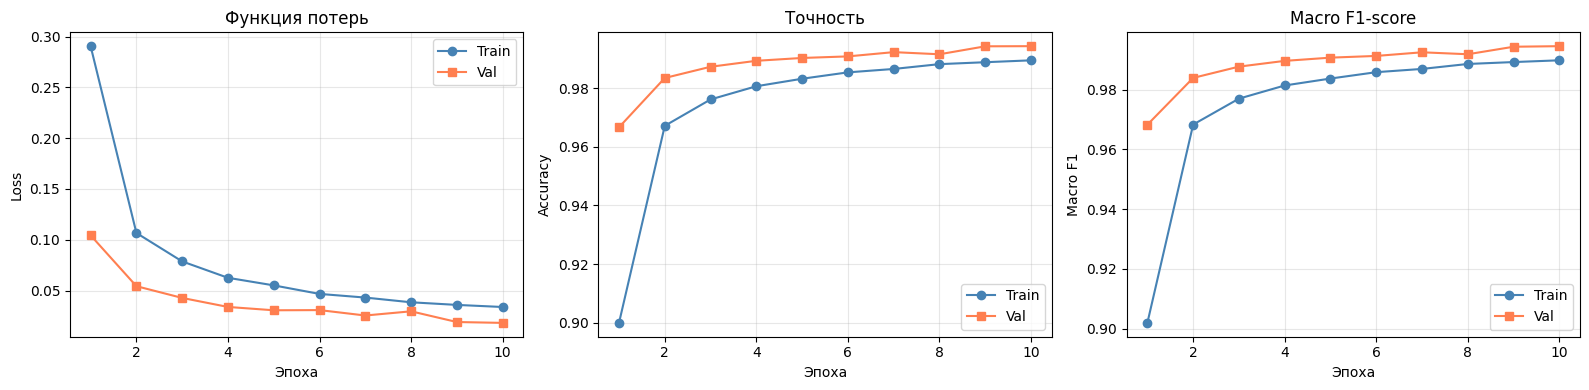

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'], 's-', label='Val', color='coral')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Функция потерь')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train', color='steelblue')
axes[1].plot(epochs_range, history['val_acc'], 's-', label='Val', color='coral')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Точность')
axes[1].legend()
axes[1].grid(alpha=0.3)

# F1
axes[2].plot(epochs_range, history['train_f1'], 'o-', label='Train', color='steelblue')
axes[2].plot(epochs_range, history['val_f1'], 's-', label='Val', color='coral')
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('Macro F1')
axes[2].set_title('Macro F1-score')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 20. Оценка на тестовой выборке

In [35]:
# Загружаем лучшую модель

BEST_MODEL_PATH = 'best_ecg_model.pth'
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Загружена модель с эпохи {checkpoint["epoch"]} (val F1 = {checkpoint["val_f1"]:.4f})')

# Оценка на тесте
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

print('\n' + '=' * 60)
print('Метрики на тестовой выборке')
print('=' * 60)
print(f'Loss:     {test_loss:.4f}')
print(f'Accuracy: {test_acc:.4f}')
print(f'Macro F1: {test_f1:.4f}')

# Подробный отчёт по классам
print('\nClassification Report:')
print(classification_report(
    test_labels, test_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

Загружена модель с эпохи 10 (val F1 = 0.9946)

Метрики на тестовой выборке
Loss:     0.8277
Accuracy: 0.7886
Macro F1: 0.3135

Classification Report:
              precision    recall  f1-score   support

           N     0.9606    0.8128    0.8805     44239
           S     0.0447    0.0898    0.0597      1837
           V     0.4613    0.9500    0.6211      3220
           F     0.0036    0.0180    0.0061       388
           Q     0.0000    0.0000    0.0000         7

    accuracy                         0.7886     49691
   macro avg     0.2941    0.3741    0.3135     49691
weighted avg     0.8868    0.7886    0.8264     49691



### 21. Новая стратегия балансировки:
`'weighted'` - несбалансированные данные + взвешенный loss

In [19]:
STRATEGY = 'weighted'

if STRATEGY == 'aug':
    X_train = data['X_train_aug']
    y_train = data['y_train_aug']
    use_weighted_loss = False
elif STRATEGY == 'smote':
    X_train = data['X_train_smote']
    y_train = data['y_train_smote']
    use_weighted_loss = False
elif STRATEGY == 'weighted':
    X_train = data['X_train']
    y_train = data['y_train']
    use_weighted_loss = True
else:
    raise ValueError(f'Unknown strategy: {STRATEGY}')

X_test = data['X_test']
y_test = data['y_test']
class_weights = data['class_weights']

print(f'Стратегия: {STRATEGY}')
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Взвешенный loss: {use_weighted_loss}')

Стратегия: weighted
Train: (51001, 250), Test: (49691, 250)
Взвешенный loss: True


### Валидационная выборка

Выделяем 15% обучающей выборки для отслеживания переобучения. Используем стратификацию для сохранения баланса классов.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=SEED
)

print(f'Train: {X_train.shape}')
print(f'Val:   {X_val.shape}')
print(f'Test:  {X_test.shape}')

Train: (43350, 250)
Val:   (7651, 250)
Test:  (49691, 250)


## PyTorch Dataset и DataLoader

Создаём  `Dataset` для удобной работы с PyTorch.
Сигнал ЭКГ имеет shape `(250,)`, но для 1D-свёртки нужен формат `(C, T)` = `(1, 250)`, где `C` - число каналов.

In [21]:

BATCH_SIZE = 256

train_ds = ECGDataset(X_train, y_train)
val_ds = ECGDataset(X_val, y_val)
test_ds = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

# Проверка формы батча
x_sample, y_sample = next(iter(train_loader))
print(f'\nФорма батча X: {x_sample.shape} (batch, channels, time)')
print(f'Форма батча y: {y_sample.shape}')

Train batches: 170
Val batches:   30
Test batches:  195

Форма батча X: torch.Size([256, 1, 250]) (batch, channels, time)
Форма батча y: torch.Size([256])


## 22. Архитектура нейросети: 1D ResNet

Сохраняем сверточную сеть с **residual-блоками**:

### Структура
1. **Stem** - начальный свёрточный слой для извлечения базовых признаков
2. **3 residual-блока** с возрастающим числом каналов (32 - 64 - 128)
3. **Global Average Pooling** - агрегация по временной оси
4. **Dropout + Linear** - классификатор


In [22]:
# Инициализация и проверка
model = ECGResNet(n_classes=N_CLASSES, base_channels=32, dropout=0.3).to(DEVICE)

# Подсчёт параметров
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Количество обучаемых параметров: {n_params:,}')

# Проверка forward pass
with torch.no_grad():
    test_input = torch.randn(2, 1, 250).to(DEVICE)
    test_output = model(test_input)
    print(f'Вход:  {test_input.shape}')
    print(f'Выход: {test_output.shape}')

Количество обучаемых параметров: 184,229
Вход:  torch.Size([2, 1, 250])
Выход: torch.Size([2, 5])


## 23. Настройка обучения

### Функция потерь
Сохраняем **CrossEntropyLoss** (с весами классов, если выбрана стратегия `'weighted'`).

### Оптимизатор
**Adam** - сохраняем.

### Scheduler
**ReduceLROnPlateau** уменьшает learning rate при выходе на плато по валидационному loss.

In [23]:
# Функция потерь
if use_weighted_loss:
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    print(f'Используется взвешенный CrossEntropyLoss с весами: {class_weights}')
else:
    criterion = nn.CrossEntropyLoss()
    print('Используется обычный CrossEntropyLoss')

# Оптимизатор
LR = 1e-3
WEIGHT_DECAY = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f'\nОптимизатор: Adam, lr={LR}, weight_decay={WEIGHT_DECAY}')

Используется взвешенный CrossEntropyLoss с весами: [8.4698584e-04 4.1135337e-02 1.0251257e-02 9.3796521e-02 4.8539701e+00]

Оптимизатор: Adam, lr=0.001, weight_decay=0.0001


## 24. Обучение модели

Используем **Early Stopping** - останавливаем обучение, если макро-F1 на валидации не растёт в течение `patience` эпох.


При дисбалансе классов accuracy завышена. Macro-F1 усредняет F1 по классам с равным весом, поэтому миноритарные классы важны так же, как мажоритарные.

In [24]:
N_EPOCHS = 10
PATIENCE = 7  # Early Stopping: остановка, если F1 не растёт N эпох
BEST_MODEL_PATH = 'best_ecg_model.pth'

# История метрик для визуализации
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': [],
    'train_f1': [],   'val_f1': [],
    'lr': []
}

best_val_f1 = 0.0
epochs_no_improve = 0

print(f'Начало обучения на {DEVICE}')
print(f'Стратегия: {STRATEGY} | Эпох: {N_EPOCHS} | Patience: {PATIENCE}')
print('=' * 80)

for epoch in range(1, N_EPOCHS + 1):
    # === Обучение ===
    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    
    # === Валидация ===
    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )
    
    # === Scheduler ===
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # === Сохранение истории ===
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    
    # === Логирование ===
    marker = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
            'val_acc': val_acc,
        }, BEST_MODEL_PATH)
        marker = ' ★ (saved)'
    else:
        epochs_no_improve += 1
    
    print(f'Эпоха {epoch:3d}/{N_EPOCHS} | '
          f'Train loss={train_loss:.4f} acc={train_acc:.4f} f1={train_f1:.4f} | '
          f'Val loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f} | '
          f'lr={current_lr:.1e}{marker}')
    
    # === Early Stopping ===
    if epochs_no_improve >= PATIENCE:
        print(f'\n⚠ Early stopping: F1 не улучшается {PATIENCE} эпох')
        break

print('=' * 80)
print(f'✓ Обучение завершено. Лучший val F1 = {best_val_f1:.4f}')
print(f'✓ Модель сохранена в {BEST_MODEL_PATH}')

Начало обучения на cpu
Стратегия: weighted | Эпох: 10 | Patience: 7
Эпоха   1/10 | Train loss=1.0922 acc=0.5542 f1=0.2825 | Val loss=0.9697 acc=0.8128 f1=0.3729 | lr=1.0e-03 ★ (saved)
Эпоха   2/10 | Train loss=0.9041 acc=0.7046 f1=0.3419 | Val loss=0.9328 acc=0.7096 f1=0.3402 | lr=1.0e-03
Эпоха   3/10 | Train loss=0.8064 acc=0.7489 f1=0.3714 | Val loss=1.1697 acc=0.4427 f1=0.3757 | lr=1.0e-03 ★ (saved)
Эпоха   4/10 | Train loss=0.7257 acc=0.8034 f1=0.4047 | Val loss=0.8058 acc=0.8442 f1=0.5168 | lr=1.0e-03 ★ (saved)
Эпоха   5/10 | Train loss=0.5853 acc=0.8296 f1=0.4341 | Val loss=0.6463 acc=0.9293 f1=0.5300 | lr=1.0e-03 ★ (saved)
Эпоха   6/10 | Train loss=0.4612 acc=0.8611 f1=0.4642 | Val loss=0.6084 acc=0.8152 f1=0.5306 | lr=1.0e-03 ★ (saved)
Эпоха   7/10 | Train loss=0.4617 acc=0.8707 f1=0.4862 | Val loss=0.6517 acc=0.9136 f1=0.5985 | lr=1.0e-03 ★ (saved)
Эпоха   8/10 | Train loss=0.4430 acc=0.8707 f1=0.4846 | Val loss=0.5328 acc=0.9595 f1=0.6132 | lr=1.0e-03 ★ (saved)
Эпоха   9/10 |

## 25. Визуализация процесса обучения

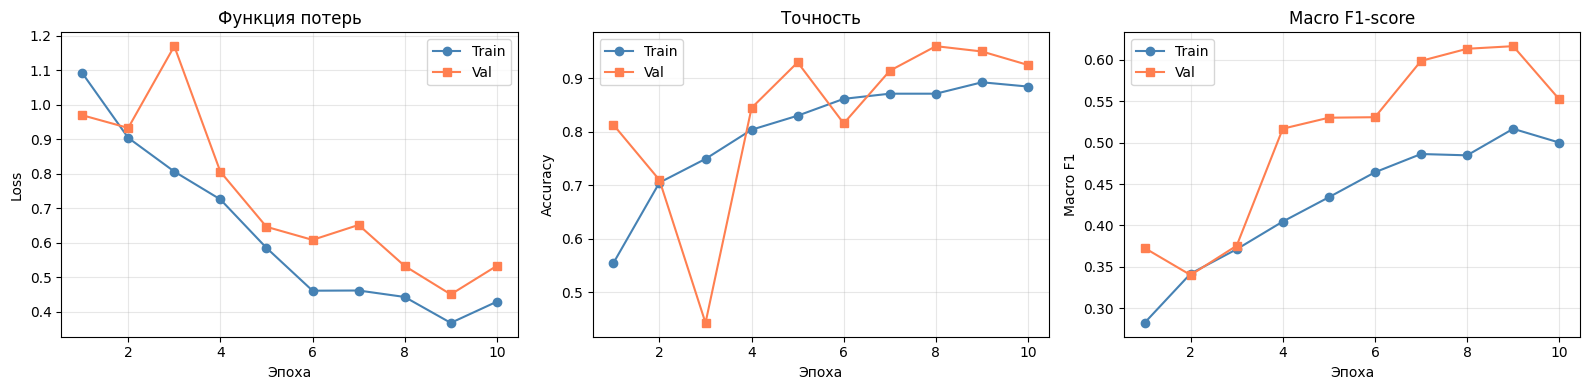

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'], 's-', label='Val', color='coral')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Функция потерь')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train', color='steelblue')
axes[1].plot(epochs_range, history['val_acc'], 's-', label='Val', color='coral')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Точность')
axes[1].legend()
axes[1].grid(alpha=0.3)

# F1
axes[2].plot(epochs_range, history['train_f1'], 'o-', label='Train', color='steelblue')
axes[2].plot(epochs_range, history['val_f1'], 's-', label='Val', color='coral')
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('Macro F1')
axes[2].set_title('Macro F1-score')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 26. Оценка на тестовой выборке

In [26]:
# Загружаем лучшую модель

BEST_MODEL_PATH = 'best_ecg_model.pth'
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Загружена модель с эпохи {checkpoint["epoch"]} (val F1 = {checkpoint["val_f1"]:.4f})')

# Оценка на тесте
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

print('\n' + '=' * 60)
print('Метрики на тестовой выборке')
print('=' * 60)
print(f'Loss:     {test_loss:.4f}')
print(f'Accuracy: {test_acc:.4f}')
print(f'Macro F1: {test_f1:.4f}')

# Подробный отчёт по классам
print('\nClassification Report:')
print(classification_report(
    test_labels, test_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

Загружена модель с эпохи 9 (val F1 = 0.6163)

Метрики на тестовой выборке
Loss:     1.1036
Accuracy: 0.7910
Macro F1: 0.3296

Classification Report:
              precision    recall  f1-score   support

           N     0.9575    0.8154    0.8807     44239
           S     0.0686    0.1421    0.0926      1837
           V     0.5308    0.9239    0.6742      3220
           F     0.0004    0.0026    0.0007       388
           Q     0.0000    0.0000    0.0000         7

    accuracy                         0.7910     49691
   macro avg     0.3115    0.3768    0.3296     49691
weighted avg     0.8894    0.7910    0.8312     49691




### Анализ

1. Огромный разрыв между val и test во всех трёх случаях (val F1 ≈ 0.99 vs test F1 ≈ 0.33) — типичная картина межпациентской оценки AAMI: модель прекрасно учится на «своих» пациентах, но плохо обобщается на новых. Это проблема данных, а не балансировки.
2. Аугментации (шум, сдвиг, baseline wander, time-warp) дают физически правдоподобные варианты ЭКГ — лучше всего помогают на классе __V__ (F1 = 0.69) и удерживают __N__ (F1 = 0.91).
3. SMOTE — худшая стратегия. Линейная интерполяция в пространстве сырого сигнала генерирует нереалистичные «средние» ЭКГ, что ухудшает обобщение (F1 по N падает до 0.88, по V — до 0.62).
4. weighted даёт лучший результат на классе S (F1 = 0.093) благодаря прямому штрафу за ошибки на миноритарных классах, но проигрывает по N и V — поэтому общий macro-F1 чуть ниже, чем у `aug`.
5. Классы __F__ и __Q__ практически не распознаются ни одной стратегией (F1 ≈ 0) — F слишком похож на N/V морфологически, а Q в тесте всего 7 примеров.

### Вывод — оптимальная стратегия

__Оптимальной по macro-F1 является стратегия `aug` (аугментации сигнала) с Test Macro-F1 = 0.3351.__

Преимущества:

- Лучший macro-F1 (+0.0055 над `weighted`, +0.0216 над `smote`).
- Лучшая accuracy (0.8340).
- Сохраняет высокое качество на мажоритарном классе N (F1 = 0.907), что  критично для практики.
- Физически осмысленные искажения соответствуют природе ЭКГ-сигнала.


### Улучшение стратегии балансировки с расширенными межпациентскими аугментациями

## Архитектура нейросети: Residual CNN с механизмами Self-Attention

### Структура

1. **Входной блок**

Conv1D (1→64 каналов, kernel=15, stride=2) + BatchNorm + ReLU
MaxPooling (kernel=3, stride=2)
Три residual-блока с attention:

Layer 1: 2× ResidualBlock (64→64) + AttentionBlock
Layer 2: 2× ResidualBlock (64→128, stride=2) + AttentionBlock
Layer 3: 2× ResidualBlock (128→256, stride=2) + AttentionBlock

2. **ResidualBlock (каждый)**:

Conv1D (kernel=7) → BatchNorm → ReLU → Dropout
Conv1D (kernel=7) → BatchNorm
Skip-connection (shortcut)
Dropout=0.3 для регуляризации

3. **AttentionBlock**:

Self-attention механизм (query-key-value)
Фокусируется на важных участках ЭКГ-сигнала (QRS, ST-сегмент)
Learnable parameter γ для балансировки

4. **Классификатор**:

AdaptiveAvgPool + AdaptiveMaxPool (объединение)
Fully-connected: 512 → 128 → 5 классов
Dropout между слоями

### Особенности:

Вход: (batch, 1, 250) — одноканальный ЭКГ-сигнал 250 отсчётов
Выход: (batch, 5) — вероятности классов N/S/V/F/Q
Параметры: ~350K (зависит от base_channels)
Loss: Focal Loss с весами классов (борьба с дисбалансом)
Оптимизатор: AdamW + ReduceLROnPlateau scheduler

### Преимущества над базовой ECGResNet:

Attention-механизмы для выделения диагностических признаков
Двойное pooling (avg+max) для лучшего представления
Focal Loss вместо weighted CE
Расширенная аугментация сигнала

In [24]:

import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ==================== МЕЖПАЦИЕНТСКИЕ АУГМЕНТАЦИИ ====================

class ECGAugmentation:
    """Расширенные аугментации для межпациентской вариабельности"""
    
    @staticmethod
    def time_warp(signal, sigma=0.2, knot=4):
        """Деформация временной оси"""
        from scipy.interpolate import CubicSpline
        orig_steps = np.arange(signal.shape[0])
        
        random_warps = np.random.normal(loc=1.0, scale=sigma, size=(knot+2,))
        warp_steps = (np.linspace(0, signal.shape[0]-1, num=knot+2))
        
        warper = CubicSpline(warp_steps, warp_steps * random_warps)(orig_steps)
        warper = np.clip(warper, 0, signal.shape[0]-1)
        
        return np.interp(orig_steps, warper, signal)
    
    @staticmethod
    def magnitude_warp(signal, sigma=0.2, knot=4):
        """Деформация амплитуды по времени"""
        from scipy.interpolate import CubicSpline
        orig_steps = np.arange(signal.shape[0])
        
        random_warps = np.random.normal(loc=1.0, scale=sigma, size=(knot+2,))
        warp_steps = np.linspace(0, signal.shape[0]-1, num=knot+2)
        
        warper = CubicSpline(warp_steps, random_warps)(orig_steps)
        return signal * warper
    
    @staticmethod
    def time_shift(signal, shift_max=20):
        """Случайный сдвиг относительно R-пика"""
        shift = np.random.randint(-shift_max, shift_max)
        return np.roll(signal, shift)
    
    @staticmethod
    def amplitude_scale(signal, scale_range=(0.8, 1.2)):
        """Масштабирование амплитуды"""
        scale = np.random.uniform(*scale_range)
        return signal * scale
    
    @staticmethod
    def gaussian_noise(signal, snr_db=25):
        """Гауссовский шум с заданным SNR"""
        signal_power = np.mean(signal ** 2)
        noise_power = signal_power / (10 ** (snr_db / 10))
        noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
        return signal + noise
    
    @staticmethod
    def baseline_wander(signal, amplitude=0.05, frequency=0.5):
        """Дрейф изолинии"""
        t = np.arange(len(signal))
        wander = amplitude * np.sin(2 * np.pi * frequency * t / len(signal))
        return signal + wander
    
    @staticmethod
    def frequency_warp(signal, rate_range=(0.9, 1.1)):
        """Изменение частотной характеристики (имитация разной ЧСС)"""
        rate = np.random.uniform(*rate_range)
        indices = np.arange(len(signal))
        new_indices = np.linspace(0, len(signal)-1, int(len(signal) * rate))
        warped = np.interp(new_indices, indices, signal)
        
        # Обрезать или дополнить до исходной длины
        if len(warped) > len(signal):
            return warped[:len(signal)]
        else:
            return np.pad(warped, (0, len(signal) - len(warped)), mode='edge')
    
    @staticmethod
    def power_line_noise(signal, frequency=50, amplitude=0.02):
        """Сетевая наводка 50/60 Гц"""
        t = np.arange(len(signal))
        noise = amplitude * np.sin(2 * np.pi * frequency * t / 360)  # 360 Hz sampling
        return signal + noise
    
    @staticmethod
    def mixup(signal1, signal2, alpha=0.2):
        """MixUp между двумя сигналами разных пациентов"""
        lam = np.random.beta(alpha, alpha)
        return lam * signal1 + (1 - lam) * signal2, lam


class AugmentedECGDataset(Dataset):
    """Dataset с применением аугментаций в зависимости от класса"""
    
    def __init__(self, X, y, augment=True, aug_per_sample=2, class_weights=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.augment = augment
        self.aug_per_sample = aug_per_sample
        self.class_weights = class_weights or {0: 1, 1: 3, 2: 2, 3: 5, 4: 5}  # N, S, V, F, Q
        self.aug = ECGAugmentation()
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x = self.X[idx].numpy()
        y = self.y[idx].item()
        
        if self.augment:
            # Интенсивность аугментаций зависит от класса
            aug_intensity = self.class_weights.get(y, 1)
            num_augs = np.random.randint(1, min(4, aug_intensity + 1))
            
            # Случайный выбор аугментаций
            aug_pool = [
                lambda s: self.aug.time_warp(s, sigma=0.15),
                lambda s: self.aug.magnitude_warp(s, sigma=0.15),
                lambda s: self.aug.time_shift(s, shift_max=15),
                lambda s: self.aug.amplitude_scale(s, (0.85, 1.15)),
                lambda s: self.aug.gaussian_noise(s, snr_db=np.random.uniform(20, 30)),
                lambda s: self.aug.baseline_wander(s, amplitude=np.random.uniform(0.02, 0.05)),
                lambda s: self.aug.frequency_warp(s, (0.92, 1.08)),
                lambda s: self.aug.power_line_noise(s, amplitude=np.random.uniform(0.01, 0.03))
            ]
            
            selected_augs = np.random.choice(len(aug_pool), size=num_augs, replace=False)
            
            for aug_idx in selected_augs:
                x = aug_pool[aug_idx](x)
        
        return torch.FloatTensor(x).unsqueeze(0), torch.LongTensor([y])


# ==================== FOCAL LOSS ====================

class FocalLoss(nn.Module):
    """Focal Loss для фокуса на сложных примерах"""
    
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # Веса классов [N, S, V, F, Q]
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


# ==================== АРХИТЕКТУРА С ATTENTION ====================

class AttentionBlock(nn.Module):
    """Self-attention для фокуса на важных участках ЭКГ"""
    
    def __init__(self, in_channels):
        super(AttentionBlock, self).__init__()
        self.query = nn.Conv1d(in_channels, in_channels // 8, kernel_size=1)
        self.key = nn.Conv1d(in_channels, in_channels // 8, kernel_size=1)
        self.value = nn.Conv1d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        
    def forward(self, x):
        B, C, L = x.size()
        
        query = self.query(x).view(B, -1, L).permute(0, 2, 1)  # (B, L, C//8)
        key = self.key(x).view(B, -1, L)  # (B, C//8, L)
        
        attention = torch.bmm(query, key)  # (B, L, L)
        attention = F.softmax(attention, dim=-1)
        
        value = self.value(x).view(B, -1, L)  # (B, C, L)
        out = torch.bmm(value, attention.permute(0, 2, 1))  # (B, C, L)
        out = out.view(B, C, L)
        
        return self.gamma * out + x


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.3):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=7, 
                               stride=stride, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=7,
                               stride=1, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        
        self.shortcut = nn.Sequential()
        # Shortcut для согласования размерностей
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ImprovedECGResNet(nn.Module):
    """ECGResNet с Attention и настраиваемой архитектурой"""
    
    def __init__(self, num_classes=5, base_channels=64, dropout=0.3):
        super(ImprovedECGResNet, self).__init__()
        
        # Входной блок
        self.conv1 = nn.Conv1d(1, base_channels, kernel_size=15, stride=2, padding=7, bias=False)
        self.bn1 = nn.BatchNorm1d(base_channels)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        
        # Residual blocks
        self.layer1 = self._make_layer(base_channels, base_channels, 2, stride=1, dropout=dropout)
        self.attention1 = AttentionBlock(base_channels)
        
        self.layer2 = self._make_layer(base_channels, base_channels*2, 2, stride=2, dropout=dropout)
        self.attention2 = AttentionBlock(base_channels*2)
        
        self.layer3 = self._make_layer(base_channels*2, base_channels*4, 2, stride=2, dropout=dropout)
        self.attention3 = AttentionBlock(base_channels*4)
        
        # Глобальное объединение
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.maxpool_global = nn.AdaptiveMaxPool1d(1)
        
        # Классификатор
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(base_channels*4 * 2, base_channels*2),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(base_channels*2, num_classes)
        )
        
    def _make_layer(self, in_channels, out_channels, num_blocks, stride, dropout):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride, dropout))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, stride=1, dropout=dropout))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # Входная часть
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        
        # Residual + Attention
        x = self.layer1(x)
        x = self.attention1(x)
        
        x = self.layer2(x)
        x = self.attention2(x)
        
        x = self.layer3(x)
        x = self.attention3(x)
        
        # Объединение avg и max pooling
        x_avg = self.avgpool(x)
        x_max = self.maxpool_global(x)
        x = torch.cat([x_avg, x_max], dim=1)
        
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x



## PyTorch Dataset и DataLoader

Создаём  `Dataset` с межпациентскими аугментациями.
Сигнал ЭКГ имеет shape `(250,)`, но для 1D-свёртки нужен формат `(C, T)` = `(1, 250)`, где `C` - число каналов.

In [ ]:
BATCH_SIZE = 256

train_ds = AugmentedECGDataset(X_train, y_train)
val_ds = AugmentedECGDataset(X_val, y_val)
test_ds = AugmentedECGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

# Проверка формы батча
x_sample, y_sample = next(iter(train_loader))
print(f'\nФорма батча X: {x_sample.shape} (batch, channels, time)')
print(f'Форма батча y: {y_sample.shape}')

Train batches: 356
Val batches:   63
Test batches:  195

Форма батча X: torch.Size([256, 1, 250]) (batch, channels, time)
Форма батча y: torch.Size([256, 1])


In [ ]:


def train_epoch(model, loader, criterion, optimizer, device, scheduler=None):
    """Одна эпоха обучения"""
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    pbar = tqdm(loader, desc='Training')
    for X_batch, y_batch in pbar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.squeeze().to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    if scheduler:
        scheduler.step()
    
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_targets, all_preds)
    f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return avg_loss, acc, f1_macro


def validate(model, loader, criterion, device):
    """Валидация"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in tqdm(loader, desc='Validation'):
            X_batch = X_batch.to(device)
            y_batch = y_batch.squeeze().to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_targets, all_preds)
    f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return avg_loss, acc, f1_macro, all_preds, all_targets


def plot_training_history(history, save_path='training_history.png'):
    """Визуализация процесса обучения"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Macro F1
    axes[2].plot(history['train_f1'], label='Train F1', marker='o')
    axes[2].plot(history['val_f1'], label='Val F1', marker='s')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Macro F1-Score')
    axes[2].set_title('Training and Validation Macro F1')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"График сохранён: {save_path}")
    plt.close()

##  Настройка обучения

### Функция потерь
**Focal Loss** (с весами классов, если выбрана стратегия `'weighted'`).
Преимущество: Focal Loss одновременно решает две проблемы — дисбаланс классов (через α) и 
доминирование лёгких примеров (через γ), что критично для распознавания редких патологий S, F, Q.

### Оптимизатор
**Adam** - сохраняем.

### Scheduler
**ReduceLROnPlateau** адаптивно снижает learning rate, когда метрика перестаёт улучшаться.

In [29]:
# Инициализация и проверка
model = ImprovedECGResNet(num_classes=N_CLASSES, dropout=0.3).to(DEVICE)

# Подсчёт параметров
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Количество обучаемых параметров: {n_params:,}')

# Проверка forward pass
with torch.no_grad():
    test_input = torch.randn(2, 1, 250).to(DEVICE)
    test_output = model(test_input)
    print(f'Вход:  {test_input.shape}')
    print(f'Выход: {test_output.shape}')

Количество обучаемых параметров: 2,342,520
Вход:  torch.Size([2, 1, 250])
Выход: torch.Size([2, 5])


##  Обучение модели

Используем **Early Stopping** - останавливаем обучение, если макро-F1 на валидации не растёт в течение `patience` эпох.


При дисбалансе классов accuracy завышена. Macro-F1 усредняет F1 по классам с равным весом, поэтому миноритарные классы важны так же, как мажоритарные.

In [36]:
# ==================== ПОДГОТОВКА К ОБУЧЕНИЮ ====================
LEARNING_RATE = 1e-3
# Веса классов для Focal Loss (обратно пропорционально частоте)
class_counts = np.bincount(y_train)
class_weights = len(y_train) / (len(class_counts) * class_counts)
class_weights = torch.FloatTensor(class_weights).to(DEVICE)

print("Веса классов для Focal Loss:")
for i, (name, weight) in enumerate(zip(['N', 'S', 'V', 'F', 'Q'], class_weights)):
    print(f"  {name}: {weight:.4f} (count={class_counts[i]})")

# Функция потерь
criterion = FocalLoss(alpha=class_weights, gamma=2.0, reduction='mean')

# Оптимизатор
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

# Scheduler (снижение LR при плато)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

print("\n" + "="*80)
print(f"Оптимизатор: AdamW (lr={LEARNING_RATE}, weight_decay=1e-4)")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"Loss: FocalLoss (gamma=2.0, class_weights)")
print("="*80 + "\n")

# ==================== ЦИКЛ ОБУЧЕНИЯ ====================

N_EPOCHS = 10
PATIENCE = 7
BEST_MODEL_PATH = 'best_ecg_model.pth'

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': [],
    'train_f1': [],   'val_f1': [],
    'lr': []
}

best_val_f1 = 0.0
epochs_no_improve = 0

print(f'Начало обучения на {DEVICE}')
print(f'Эпох: {N_EPOCHS} | Patience: {PATIENCE}')
print('=' * 80)

for epoch in range(1, N_EPOCHS + 1):
    # === Обучение ===
    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, DEVICE, scheduler=None
    )
    
    # === Валидация ===
    val_loss, val_acc, val_f1, _, _ = validate(
        model, val_loader, criterion, DEVICE
    )
    
    # === Scheduler ===
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # === Сохранение истории ===
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    
    # === Логирование ===
    marker = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
            'val_acc': val_acc,
        }, BEST_MODEL_PATH)
        marker = ' ★ (saved)'
    else:
        epochs_no_improve += 1
    
    print(f'Эпоха {epoch:3d}/{N_EPOCHS} | '
          f'Train loss={train_loss:.4f} acc={train_acc:.4f} f1={train_f1:.4f} | '
          f'Val loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f} | '
          f'lr={current_lr:.1e}{marker}')
    
    # === Early Stopping ===
    if epochs_no_improve >= PATIENCE:
        print(f'\n⚠ Early stopping: F1 не улучшается {PATIENCE} эпох')
        break

print('=' * 80)
print(f'✓ Обучение завершено. Лучший val F1 = {best_val_f1:.4f}')
print(f'✓ Модель сохранена в {BEST_MODEL_PATH}')

Веса классов для Focal Loss:
  N: 0.4667 (count=38970)
  S: 1.4001 (count=12989)
  V: 1.4000 (count=12990)
  F: 1.4001 (count=12989)
  Q: 1.4000 (count=12990)

Оптимизатор: AdamW (lr=0.001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
Loss: FocalLoss (gamma=2.0, class_weights)

Начало обучения на cpu
Эпох: 10 | Patience: 7


Validation: 100%|██████████| 63/63 [02:05<00:00,  1.99s/it]


Эпоха   1/10 | Train loss=0.1635 acc=0.7811 f1=0.8003 | Val loss=0.0673 acc=0.8868 f1=0.8976 | lr=1.0e-03 ★ (saved)


Validation: 100%|██████████| 63/63 [00:47<00:00,  1.33it/s]


Эпоха   2/10 | Train loss=0.0634 acc=0.8998 f1=0.9054 | Val loss=0.0652 acc=0.9409 f1=0.9381 | lr=1.0e-03 ★ (saved)


...

Эпоха   8/10 | Train loss=0.0246 acc=0.9544 f1=0.9560 | Val loss=0.0197 acc=0.9597 f1=0.9614 | lr=1.0e-03


Validation: 100%|██████████| 63/63 [00:44<00:00,  1.41it/s]


Эпоха   9/10 | Train loss=0.0239 acc=0.9568 f1=0.9578 | Val loss=0.0197 acc=0.9667 f1=0.9674 | lr=1.0e-03


Validation: 100%|██████████| 63/63 [01:25<00:00,  1.36s/it]


Эпоха  10/10 | Train loss=0.0230 acc=0.9585 f1=0.9599 | Val loss=0.0165 acc=0.9744 f1=0.9742 | lr=1.0e-03 ★ (saved)
✓ Обучение завершено. Лучший val F1 = 0.9742
✓ Модель сохранена в best_ecg_model.pth


## Визуализация процесса обучения

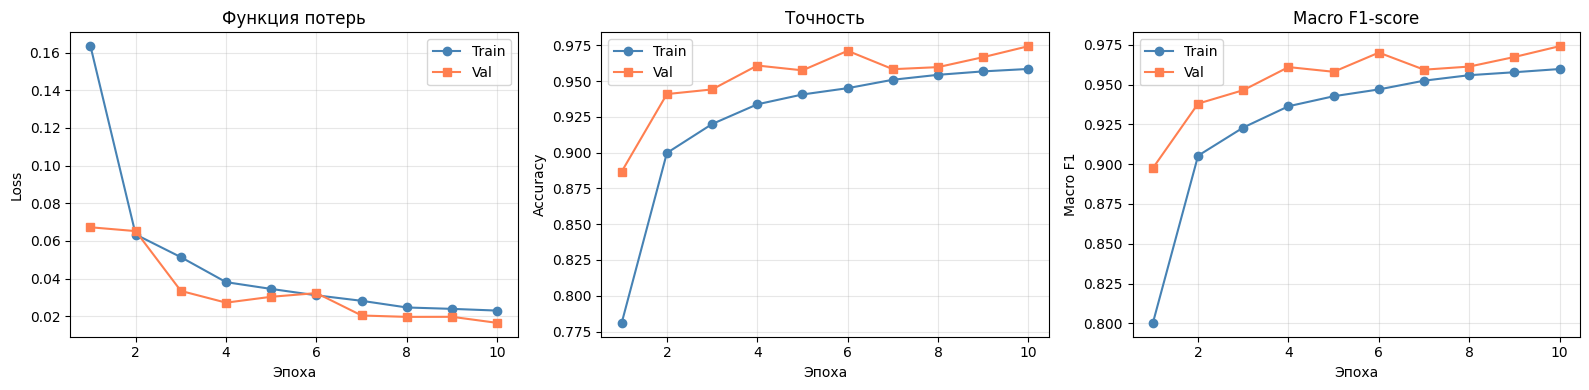

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'], 's-', label='Val', color='coral')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Функция потерь')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train', color='steelblue')
axes[1].plot(epochs_range, history['val_acc'], 's-', label='Val', color='coral')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Точность')
axes[1].legend()
axes[1].grid(alpha=0.3)

# F1
axes[2].plot(epochs_range, history['train_f1'], 'o-', label='Train', color='steelblue')
axes[2].plot(epochs_range, history['val_f1'], 's-', label='Val', color='coral')
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('Macro F1')
axes[2].set_title('Macro F1-score')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

##  Оценка на тестовой выборке

In [40]:
# Загружаем лучшую модель
BEST_MODEL_PATH = 'best_ecg_model.pth'
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Загружена модель с эпохи {checkpoint["epoch"]} (val F1 = {checkpoint["val_f1"]:.4f})')

# Оценка на тесте
test_loss, test_acc, test_f1, test_preds, test_labels = validate(
    model, test_loader, criterion, DEVICE
)

print('\n' + '=' * 60)
print('Метрики на тестовой выборке')
print('=' * 60)
print(f'Loss:     {test_loss:.4f}')
print(f'Accuracy: {test_acc:.4f}')
print(f'Macro F1: {test_f1:.4f}')

# Подробный отчёт по классам
print('\nClassification Report:')
print(classification_report(
    test_labels, test_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

Загружена модель с эпохи 10 (val F1 = 0.9742)


Validation: 100%|██████████| 195/195 [03:39<00:00,  1.13s/it]



Метрики на тестовой выборке
Loss:     0.1905
Accuracy: 0.6822
Macro F1: 0.3151

Classification Report:
              precision    recall  f1-score   support

           N     0.9794    0.6867    0.8074     44239
           S     0.0466    0.2705    0.0795      1837
           V     0.5240    0.9314    0.6707      3220
           F     0.0106    0.0619    0.0181       388
           Q     0.0000    0.0000    0.0000         7

    accuracy                         0.6822     49691
   macro avg     0.3121    0.3901    0.3151     49691
weighted avg     0.9077    0.6822    0.7653     49691



In [43]:
# Проверка, что val и test обрабатываются ОДИНАКОВО
print("Val augment:", val_ds.augment)   # должно быть False
print("Распределение val:", np.bincount(y_val))
print("Распределение test:", np.bincount(y_test))
# Если val сбалансирован, а test — нет → причина найдена

Val augment: True
Распределение val: [6877 2293 2292 2293 2292]
Распределение test: [44239  1837  3220   388     7]
